# Análise de Tarifas Horossazonais — ANEEL

## Objetivo
Analisar especificamente a estrutura **horária e sazonal** das tarifas homologadas das distribuidoras de energia elétrica, utilizando o conjunto de dados fornecido da ANEEL.

### Perguntas da análise
1. Quais modalidades tarifárias possuem diferenciação por posto horário?
2. Como as tarifas de **Ponta**, **Fora ponta** e **Intermediário** se comportam?
3. Qual é o impacto da sazonalidade **seca x úmida**?
4. Como TE e TUSD variam entre ponta e fora ponta?
5. Quais distribuidoras apresentam maior diferencial tarifário?
6. Como esse diferencial evolui ao longo do tempo?

> **Critério:** as comparações de valores monetários serão feitas separando a unidade da tarifa. TE é R$/MWh; TUSD pode ser R$/MWh ou R$/kW. O dicionário da ANEEL também define `NomPostoTarifario` como o período em horas usado para aplicação diferenciada das tarifas.

Fonte: https://dadosabertos.aneel.gov.br/dataset/tarifas-distribuidoras-energia-eletrica


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = "tarifas-homologadas-distribuidoras-energia-eletrica.csv"
df = pd.read_csv(DATA_PATH, sep=None, engine="python")
print(f"Registros: {len(df):,}")
print(f"Colunas: {df.shape[1]}")
df.head()

Registros: 328,293
Colunas: 17


,DatGeracaoConjuntoDados,DscREH,SigAgente,NumCNPJDistribuidora,DatInicioVigencia,DatFimVigencia,DscBaseTarifaria,DscSubGrupo,DscModalidadeTarifaria,DscClasse,DscSubClasse,DscDetalhe,NomPostoTarifario,DscUnidadeTerciaria,SigAgenteAcessante,VlrTUSD,VlrTE
0,2026-10-05,"RESOLUÇÃO HOMOLOGATÓRIA Nº 0.937, DE 2 DE FEVE...",CPFL JAGUARI,53859112000169,2010-02-03,2011-02-02,Base Econômica,A2,Azul,Não se aplica,Não se aplica,APE,Fora ponta,kW,Não se aplica,"1,85",",00"
1,2026-10-05,"RESOLUÇÃO HOMOLOGATÓRIA Nº 0.937, DE 2 DE FEVE...",CPFL JAGUARI,53859112000169,2010-02-03,2011-02-02,Tarifa de Aplicação,A2,Azul,Não se aplica,Não se aplica,APE,Fora ponta,kW,Não se aplica,"1,85",",00"
2,2026-10-05,"RESOLUÇÃO HOMOLOGATÓRIA Nº 0.937, DE 2 DE FEVE...",CPFL JAGUARI,53859112000169,2010-02-03,2011-02-02,Tarifa de Aplicação,A2,Azul,Não se aplica,Não se aplica,APE,Ponta,kW,Não se aplica,"20,64",",00"
3,2026-10-05,"RESOLUÇÃO HOMOLOGATÓRIA Nº 0.937, DE 2 DE FEVE...",CPFL JAGUARI,53859112000169,2010-02-03,2011-02-02,Base Econômica,A2,Azul,Não se aplica,Não se aplica,APE,Ponta,kW,Não se aplica,"19,05",",00"
4,2026-10-05,"RESOLUÇÃO HOMOLOGATÓRIA Nº 0.937, DE 2 DE FEVE...",CPFL JAGUARI,53859112000169,2010-02-03,2011-02-02,Base Econômica,A2,Azul,Não se aplica,Não se aplica,Não se aplica,Fora ponta,kW,Não se aplica,"1,85",",00"


In [37]:
# Conversão das datas e valores monetários
for c in ["DatGeracaoConjuntoDados", "DatInicioVigencia", "DatFimVigencia"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")

for c in ["VlrTUSD", "VlrTE"]:
    df[c] = (df[c].astype(str).str.strip()
             .replace({"Não se aplica": np.nan, "": np.nan})
             .str.replace(".", "", regex=False)
             .str.replace(",", ".", regex=False))
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Período:", df.DatInicioVigencia.min().date(), "a", df.DatFimVigencia.max().date())


Período: 2010-02-03 a 2027-09-21


## 1. Estrutura horária e sazonal

A variável central desta análise é `NomPostoTarifario`. Vamos verificar quantos registros existem em cada posto e cruzar essa informação com a modalidade tarifária.

,quantidade
NomPostoTarifario,
Não se aplica,133915
Ponta,80545
Fora ponta,80543
Intermediário,24210
Fora ponta seca,2270
Fora ponta úmida,2270
Ponta seca,2270
Ponta úmida,2270


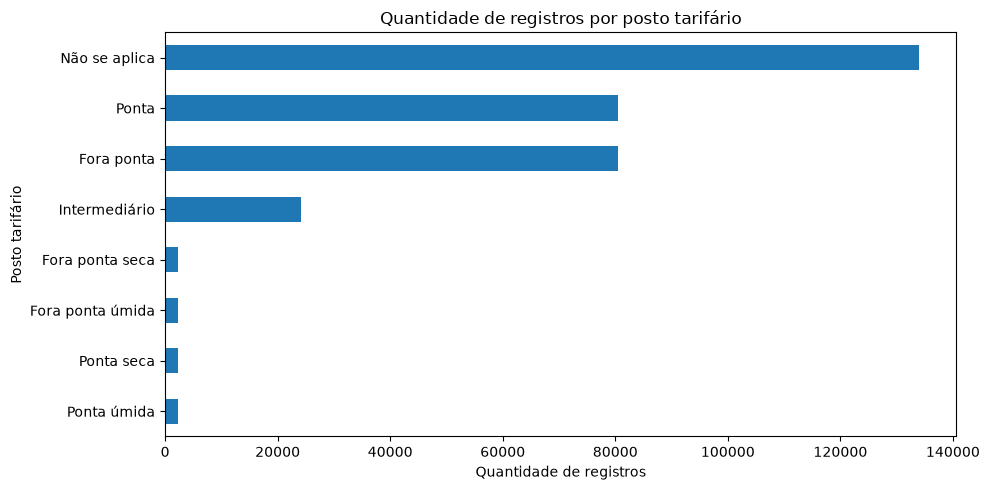

In [38]:
postos = df["NomPostoTarifario"].value_counts(dropna=False)
display(postos.to_frame("quantidade"))

plt.figure(figsize=(10,5))
postos.sort_values().plot(kind="barh")
plt.title("Quantidade de registros por posto tarifário")
plt.xlabel("Quantidade de registros")
plt.ylabel("Posto tarifário")
plt.tight_layout()
plt.show()

In [39]:
modalidade_posto = pd.crosstab(df["DscModalidadeTarifaria"], df["NomPostoTarifario"])
display(modalidade_posto)

NomPostoTarifario,Fora ponta,Fora ponta seca,Fora ponta úmida,Intermediário,Não se aplica,Ponta,Ponta seca,Ponta úmida
DscModalidadeTarifaria,,,,,,,,
Azul,38895,1340,1340,0,0,38895,1340,1340
Azul ABRACE CATIVO,0,0,0,0,201,0,0,0
Azul ABRACE LIVRE,0,0,0,0,201,0,0,0
Branca,23712,0,0,24210,108,23712,0,0
Convencional,4,0,0,0,56508,4,0,0
Convencional ABRACE,0,0,0,0,326,2,0,0
Convencional pré-pagamento,0,0,0,0,26132,0,0,0
Distribuição,6642,0,0,0,6742,6642,0,0
Energia suprimento,0,0,0,0,516,0,0,0


### Interpretação

O conjunto contém explicitamente os postos **Ponta**, **Fora ponta**, **Intermediário**, além de **Ponta seca**, **Ponta úmida**, **Fora ponta seca** e **Fora ponta úmida**. A análise, portanto, consegue estudar simultaneamente o efeito do horário e da sazonalidade.

## 2. Recorte principal: modalidades horárias

Para a análise horossazonal, o foco será principalmente nas modalidades **Azul** e **Verde**, que apresentam registros de ponta e fora ponta. A modalidade Branca também possui diferenciação horária, mas tem posto `Intermediário` no conjunto e será analisada separadamente.

In [40]:
horaria = df[df["DscModalidadeTarifaria"].isin(["Azul", "Verde", "Branca"])].copy()

resumo_modalidade = (horaria.groupby(["DscModalidadeTarifaria", "NomPostoTarifario"])
                     .size().reset_index(name="registros"))
display(resumo_modalidade)

,DscModalidadeTarifaria,NomPostoTarifario,registros
0,Azul,Fora ponta,38895
1,Azul,Fora ponta seca,1340
2,Azul,Fora ponta úmida,1340
3,Azul,Ponta,38895
4,Azul,Ponta seca,1340
5,Azul,Ponta úmida,1340
6,Branca,Fora ponta,23712
7,Branca,Intermediário,24210
8,Branca,Não se aplica,108
9,Branca,Ponta,23712


## 3. Tarifa de Energia (TE): Ponta x Fora ponta

Para evitar misturar estruturas tarifárias diferentes, a comparação será segmentada por distribuidora, modalidade e subgrupo. Primeiro observamos as medianas gerais dos registros de **Tarifa de Aplicação** em R$/MWh.

In [41]:
base = df[(df["DscBaseTarifaria"] == "Tarifa de Aplicação") &
         (df["DscUnidadeTerciaria"] == "MWh") &
         (df["DscModalidadeTarifaria"].isin(["Azul", "Verde"])) &
         (df["NomPostoTarifario"].isin(["Ponta", "Fora ponta"]))].copy()

te_resumo = (base.groupby(["DscModalidadeTarifaria", "NomPostoTarifario"])["VlrTE"]
             .agg(["count","median","mean","min","max"]).reset_index())
display(te_resumo)

,DscModalidadeTarifaria,NomPostoTarifario,count,median,mean,min,max
0,Azul,Fora ponta,9786,1.53,89.09,-188.22,532.90
1,Azul,Ponta,9786,0.00,134.68,-188.22,794.54
2,Verde,Fora ponta,5564,31.08,98.49,-188.22,508.42
3,Verde,Ponta,5564,30.98,144.81,-188.22,794.54


<Figure size 900x500 with 0 Axes>

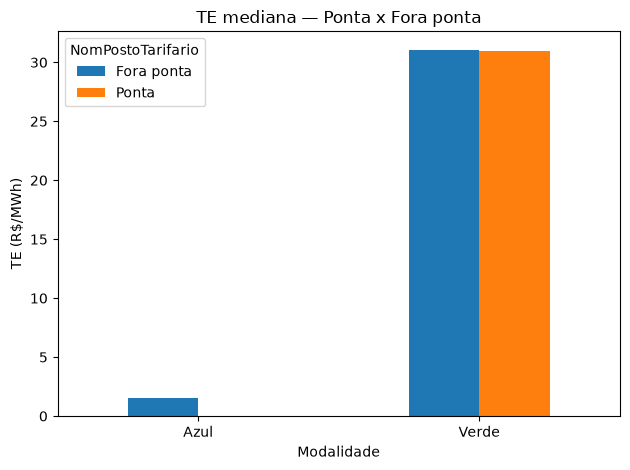

In [42]:
plt.figure(figsize=(9,5))
plot_te = base.groupby(["DscModalidadeTarifaria", "NomPostoTarifario"])["VlrTE"].median().unstack()
plot_te.plot(kind="bar")
plt.title("TE mediana — Ponta x Fora ponta")
plt.ylabel("TE (R$/MWh)")
plt.xlabel("Modalidade")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Diferencial de ponta

Para cada combinação de distribuidora, modalidade e subgrupo, calculamos:

**Diferencial de ponta (%) = (TE ponta / TE fora ponta - 1) × 100**

Esse indicador mostra quanto a tarifa de energia aumenta no posto de ponta em relação ao fora de ponta.

In [43]:
pivot_te = (base.groupby(["SigAgente", "DscModalidadeTarifaria", "DscSubGrupo", "NomPostoTarifario"])["VlrTE"]
            .median().unstack("NomPostoTarifario"))

pivot_te["Diferencial_ponta_pct"] = (pivot_te["Ponta"] / pivot_te["Fora ponta"] - 1) * 100
diferencial_te = pivot_te.dropna(subset=["Ponta", "Fora ponta"]).reset_index()

print("Maiores diferenciais de TE:")
display(diferencial_te.sort_values("Diferencial_ponta_pct", ascending=False).head(20))


Maiores diferenciais de TE:


NomPostoTarifario,SigAgente,DscModalidadeTarifaria,DscSubGrupo,Fora ponta,Ponta,Diferencial_ponta_pct
142,COOPERA,Azul,A2,85.08,145.70,71.25
322,ENF,Verde,A3a,112.92,193.25,71.13
323,ENF,Verde,A4,105.32,180.23,71.13
320,ENF,Azul,A3a,52.66,90.11,71.13
116,CFLO,Azul,A4,59.45,101.73,71.12
115,CFLO,Azul,A3a,59.45,101.73,71.12
118,CFLO,Verde,A4,123.26,210.59,70.85
117,CFLO,Verde,A3a,123.26,210.59,70.85
190,CPFL MOCOCA,Azul,A4,108.34,181.63,67.65
187,CPFL LESTE PAULI,Verde,A3a,111.75,187.32,67.62


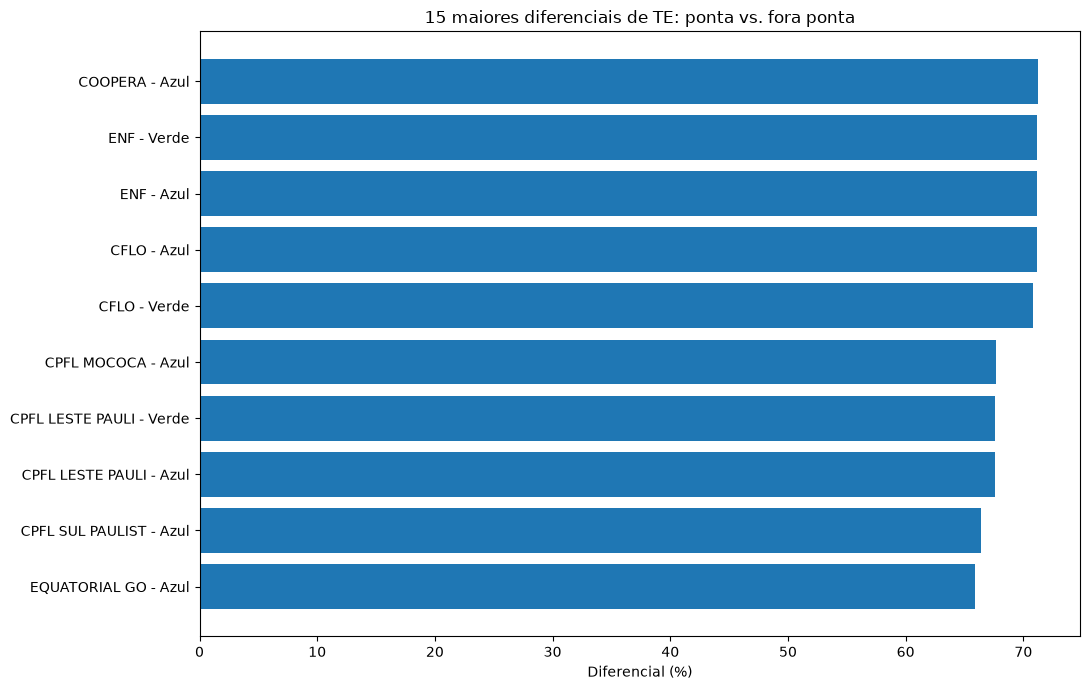

In [44]:
top = diferencial_te.sort_values("Diferencial_ponta_pct", ascending=False).head(15).copy()
labels = top["SigAgente"] + " - " + top["DscModalidadeTarifaria"]

plt.figure(figsize=(11,7))
plt.barh(labels.iloc[::-1], top["Diferencial_ponta_pct"].iloc[::-1])
plt.title("15 maiores diferenciais de TE: ponta vs. fora ponta")
plt.xlabel("Diferencial (%)")
plt.tight_layout()
plt.show()

## 5. Diferencial da TUSD

A TUSD pode estar em **R$/MWh** ou **R$/kW**. Por isso, o cálculo será realizado separadamente para cada unidade.

In [45]:
tusd_base = df[(df["DscBaseTarifaria"] == "Tarifa de Aplicação") &
             (df["DscModalidadeTarifaria"].isin(["Azul", "Verde"])) &
             (df["NomPostoTarifario"].isin(["Ponta", "Fora ponta"]))].copy()

pivot_tusd = (tusd_base.groupby(["SigAgente", "DscModalidadeTarifaria", "DscSubGrupo", "DscUnidadeTerciaria", "NomPostoTarifario"])["VlrTUSD"]
              .median().unstack("NomPostoTarifario"))
pivot_tusd["Diferencial_ponta_pct"] = (pivot_tusd["Ponta"] / pivot_tusd["Fora ponta"] - 1) * 100
dif_tusd = pivot_tusd.dropna(subset=["Ponta", "Fora ponta"]).reset_index()

for unidade in dif_tusd["DscUnidadeTerciaria"].dropna().unique():
    print(f"\nUnidade: {unidade}")
    display(dif_tusd[dif_tusd["DscUnidadeTerciaria"] == unidade]
            .sort_values("Diferencial_ponta_pct", ascending=False).head(10))


Unidade: MWh


NomPostoTarifario,SigAgente,DscModalidadeTarifaria,DscSubGrupo,DscUnidadeTerciaria,Fora ponta,Ponta,Diferencial_ponta_pct
681,RGE,Verde,AS,MWh,5.80,739.97,"12,647.20"
522,ENF,Verde,A4,MWh,15.99,"1,297.48","8,014.32"
388,EBO,Verde,A4,MWh,13.68,897.87,"6,463.38"
423,EEB,Verde,A3a,MWh,10.56,687.87,"6,413.92"
95,CERCOS,Verde,A4,MWh,45.72,"2,974.23","6,405.31"
224,COELBA,Verde,A3a,MWh,37.78,"2,061.41","5,356.35"
225,COELBA,Verde,A4,MWh,37.78,"2,061.41","5,356.35"
83,CERAL ARARUAMA,Verde,A4,MWh,83.48,"4,485.28","5,272.56"
695,SULGIPE,Verde,A4,MWh,32.33,"1,702.94","5,167.37"
299,CPFL LESTE PAULI,Verde,A3a,MWh,15.45,805.94,"5,116.44"



Unidade: kW


NomPostoTarifario,SigAgente,DscModalidadeTarifaria,DscSubGrupo,DscUnidadeTerciaria,Fora ponta,Ponta,Diferencial_ponta_pct
648,Neoenergia Brasília,Azul,B,kW,6.33,37.61,493.76
457,ELETROPAULO,Azul,B,kW,9.26,53.43,477.00
578,EQUATORIAL PI,Azul,B,kW,15.84,88.09,456.12
678,RGE,Azul,AS,kW,5.71,30.53,434.68
68,CEMIG-D,Azul,B,kW,14.21,74.00,420.76
165,CERTEL ENERGIA,Azul,A3a,kW,4.33,22.12,410.85
390,EDEVP,Azul,A2,kW,1.32,6.42,386.36
630,LIGHT SESA,Azul,B,kW,13.34,63.84,378.56
373,DMED,Azul,AS,kW,11.66,55.33,374.49
49,CELESC,Azul,B,kW,9.02,42.57,371.95


## 6. Sazonalidade: período seco x úmido

A base possui explicitamente os postos `Ponta seca`, `Ponta úmida`, `Fora ponta seca` e `Fora ponta úmida`. Aqui analisamos a diferença entre os períodos seco e úmido.

In [46]:
sazonal = df[(df["DscBaseTarifaria"] == "Tarifa de Aplicação") &
            (df["DscUnidadeTerciaria"] == "MWh") &
            (df["NomPostoTarifario"].isin(["Ponta seca", "Ponta úmida", "Fora ponta seca", "Fora ponta úmida"])) &
            (df["DscModalidadeTarifaria"].isin(["Azul", "Verde"]))].copy()

saz_resumo = (sazonal.groupby(["DscModalidadeTarifaria", "NomPostoTarifario"])[["VlrTE","VlrTUSD"]]
              .median())
display(saz_resumo)

VlrTE  VlrTUSD
DscModalidadeTarifaria NomPostoTarifario                
Azul                   Fora ponta seca   131.51    25.83
                       Fora ponta úmida  116.34    25.83
                       Ponta seca        224.43    25.83
                       Ponta úmida       200.41    25.83
Verde                  Fora ponta seca   132.93    25.95
                       Fora ponta úmida  117.66    25.95
                       Ponta seca        226.99   848.01
                       Ponta úmida       202.81   848.01

<Figure size 1000x500 with 0 Axes>

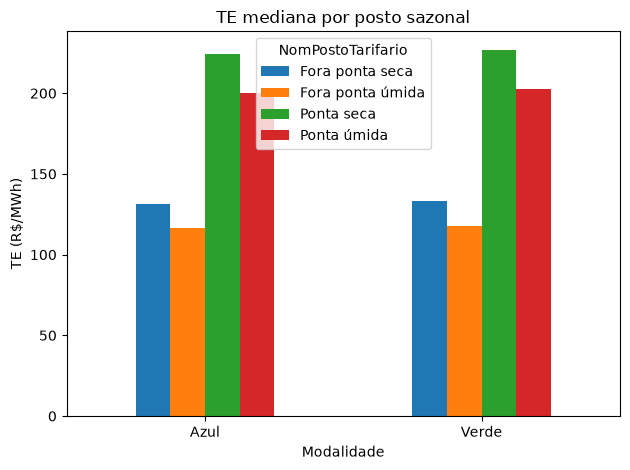

In [47]:
plt.figure(figsize=(10,5))
plot_saz = sazonal.groupby(["DscModalidadeTarifaria", "NomPostoTarifario"])["VlrTE"].median().unstack()
plot_saz.plot(kind="bar")
plt.title("TE mediana por posto sazonal")
plt.ylabel("TE (R$/MWh)")
plt.xlabel("Modalidade")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [48]:
# Indicador de sazonalidade: seco vs úmido, mantendo ponta/f.ponta separadas
saz_pivot = (sazonal.groupby(["SigAgente","DscModalidadeTarifaria","DscSubGrupo","NomPostoTarifario"])["VlrTE"]
             .median().unstack("NomPostoTarifario"))

if {"Ponta seca","Ponta úmida"}.issubset(saz_pivot.columns):
    saz_pivot["Sazonalidade_ponta_pct"] = (saz_pivot["Ponta seca"] / saz_pivot["Ponta úmida"] - 1) * 100
if {"Fora ponta seca","Fora ponta úmida"}.issubset(saz_pivot.columns):
    saz_pivot["Sazonalidade_fora_ponta_pct"] = (saz_pivot["Fora ponta seca"] / saz_pivot["Fora ponta úmida"] - 1) * 100

display(saz_pivot.reset_index().sort_values("Sazonalidade_ponta_pct", ascending=False).head(20))

NomPostoTarifario,SigAgente,DscModalidadeTarifaria,DscSubGrupo,Fora ponta seca,Fora ponta úmida,Ponta seca,Ponta úmida,Sazonalidade_ponta_pct,Sazonalidade_fora_ponta_pct
144,CPFL JAGUARI,Azul,A3a,137.72,98.19,189.44,141.44,33.94,40.25
145,CPFL JAGUARI,Azul,A4,137.72,98.19,189.44,141.44,33.94,40.25
147,CPFL JAGUARI,Verde,A4,137.72,98.19,189.44,141.44,33.94,40.25
143,CPFL JAGUARI,Azul,A2,137.72,98.19,189.44,141.44,33.94,40.25
146,CPFL JAGUARI,Verde,A3a,137.72,98.19,189.44,141.44,33.94,40.25
152,CPFL MOCOCA,Azul,A3a,169.69,121.22,233.84,174.90,33.70,39.98
154,CPFL MOCOCA,Verde,A3a,169.69,121.22,233.84,174.90,33.70,39.98
155,CPFL MOCOCA,Verde,A4,169.69,121.22,233.84,174.90,33.70,39.98
153,CPFL MOCOCA,Azul,A4,169.69,121.22,233.84,174.90,33.70,39.98
163,CPFL SUL PAULIST,Azul,A4,149.72,107.00,206.41,154.46,33.63,39.93


## 7. Evolução temporal do diferencial de ponta

Agora verificamos se o diferencial entre ponta e fora ponta mudou ao longo dos anos.

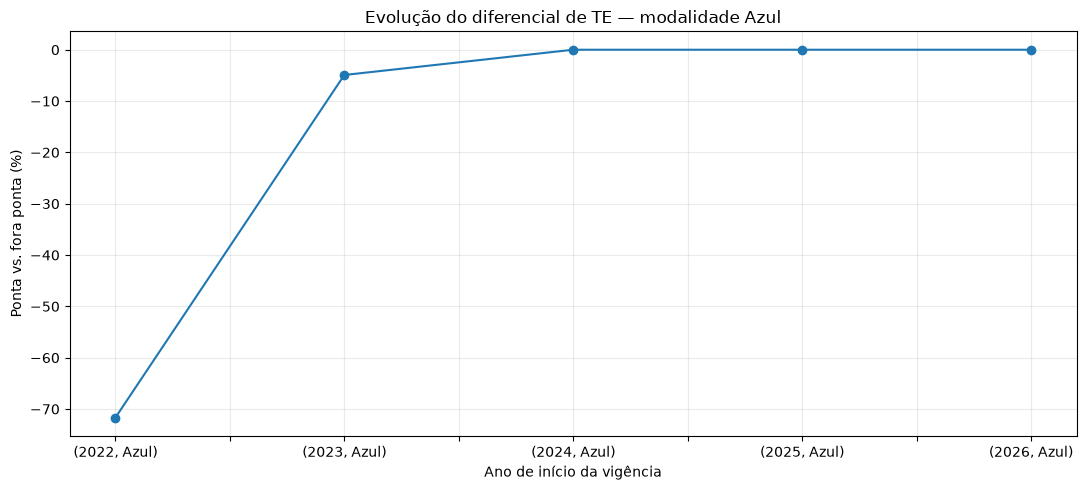

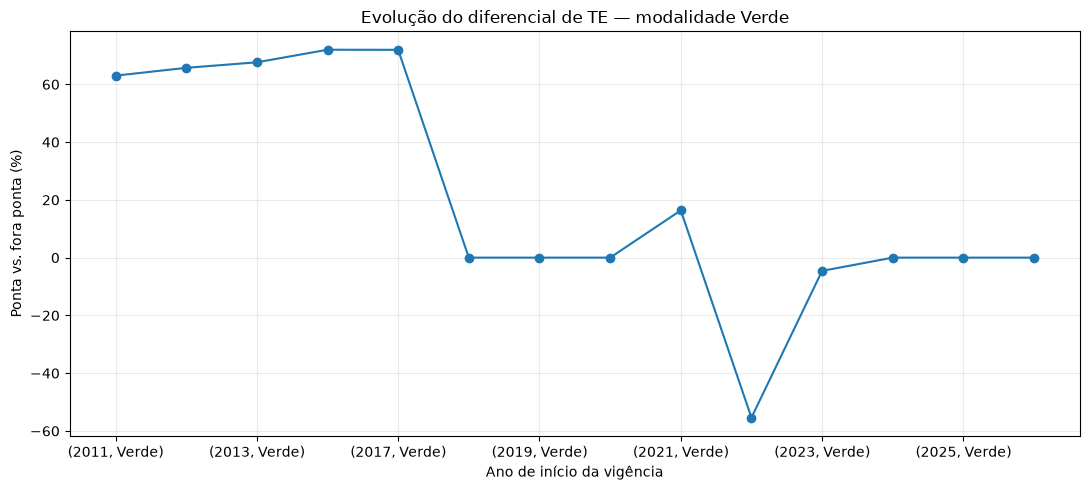

In [49]:
evol = base.copy()
evol["Ano"] = evol["DatInicioVigencia"].dt.year

evol_pivot = (evol.groupby(["Ano","DscModalidadeTarifaria","NomPostoTarifario"])["VlrTE"]
              .median().unstack("NomPostoTarifario"))
evol_pivot["Diferencial_pct"] = (evol_pivot["Ponta"] / evol_pivot["Fora ponta"] - 1) * 100

for mod in ["Azul", "Verde"]:
    serie = evol_pivot.xs(mod, level="DscModalidadeTarifaria", drop_level=False)["Diferencial_pct"].dropna()
    plt.figure(figsize=(11,5))
    serie.plot(marker="o")
    plt.title(f"Evolução do diferencial de TE — modalidade {mod}")
    plt.ylabel("Ponta vs. fora ponta (%)")
    plt.xlabel("Ano de início da vigência")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 8. Recorte das tarifas vigentes em 06/10/2026

Para uma visão atual, selecionamos registros cuja vigência contém a data de análise. Depois calculamos o diferencial de ponta apenas para tarifas de aplicação comparáveis.

In [50]:
DATA_ANALISE = pd.Timestamp("2026-10-06")
vig = df[(df["DatInicioVigencia"] <= DATA_ANALISE) & (df["DatFimVigencia"] >= DATA_ANALISE)].copy()

vig_horaria = vig[(vig["DscBaseTarifaria"] == "Tarifa de Aplicação") &
                  (vig["DscUnidadeTerciaria"] == "MWh") &
                  (vig["DscModalidadeTarifaria"].isin(["Azul","Verde"])) &
                  (vig["NomPostoTarifario"].isin(["Ponta","Fora ponta"]))].copy()

print(f"Registros vigentes: {len(vig):,}")
print(f"Distribuidoras no recorte: {vig['SigAgente'].nunique()}")

vig_pivot = (vig_horaria.groupby(["SigAgente","DscModalidadeTarifaria","DscSubGrupo","NomPostoTarifario"])["VlrTE"]
              .median().unstack("NomPostoTarifario"))
vig_pivot["Diferencial_ponta_pct"] = (vig_pivot["Ponta"] / vig_pivot["Fora ponta"] - 1) * 100
vig_dif = vig_pivot.dropna(subset=["Ponta","Fora ponta"]).reset_index()

display(vig_dif.sort_values("Diferencial_ponta_pct", ascending=False).head(25))

Registros vigentes: 21,766
Distribuidoras no recorte: 81


NomPostoTarifario,SigAgente,DscModalidadeTarifaria,DscSubGrupo,Fora ponta,Ponta,Diferencial_ponta_pct
237,ERO,Azul,A2,67.63,160.34,137.07
1,CASTRO-DIS,Verde,A4,0.38,0.38,0.00
8,CEDRAP,Azul,A4,37.42,37.42,0.00
9,CEDRAP,Verde,A4,37.42,37.42,0.00
10,CEEE-D,Azul,A2,43.98,43.98,0.00
11,CEEE-D,Azul,A3,43.98,43.98,0.00
12,CEEE-D,Azul,A4,50.23,50.23,0.00
13,CEEE-D,Azul,AS,55.36,55.36,0.00
0,CASTRO-DIS,Azul,A4,0.38,0.38,0.00
15,CEEE-D,Verde,AS,55.36,55.36,0.00


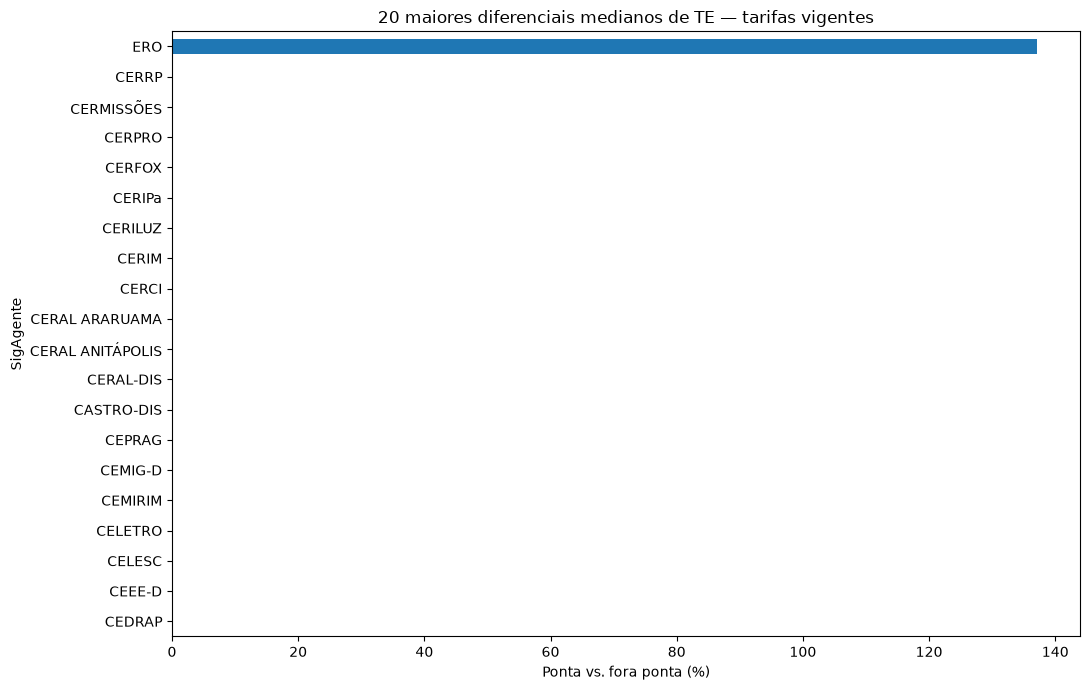

In [51]:
# Ranking por distribuidora, consolidando as combinações disponíveis
ranking_vigente = (vig_dif.groupby("SigAgente")["Diferencial_ponta_pct"]
                   .median().sort_values(ascending=False))

plt.figure(figsize=(11,7))
ranking_vigente.head(20).sort_values().plot(kind="barh")
plt.title("20 maiores diferenciais medianos de TE — tarifas vigentes")
plt.xlabel("Ponta vs. fora ponta (%)")
plt.tight_layout()
plt.show()

## 9. Conclusões

### O que a base permite concluir
- Existe informação explícita de **posto tarifário**, incluindo ponta e fora ponta.
- A base também registra a diferenciação **seca/úmida**, permitindo uma análise horossazonal.
- As modalidades **Azul** e **Verde** concentram a estrutura de ponta/fora ponta mais diretamente associada às tarifas horárias de alta tensão.
- A comparação deve ser feita mantendo a mesma distribuidora, modalidade, subgrupo, unidade e base tarifária sempre que possível.
- Para TUSD, R$/kW e R$/MWh não podem ser tratados como a mesma grandeza.


---
# Estado de São Paulo: custo da tarifa horossazonal em **R$/kWh**

## Objetivo
Responder, para as distribuidoras do estado de São Paulo, **quanto custa o kWh** nos postos horossazonais (**Ponta** e **Fora ponta**) das modalidades **Azul** e **Verde**.

## Como o R$/kWh é obtido
Os valores do CSV estão em **R$/MWh** (TE e parte da TUSD) ou **R$/kW** (TUSD de demanda). Para chegar a R$/kWh:

- **Tarifa de energia (R$/kWh)** = (TUSD em R$/MWh + TE em R$/MWh) ÷ 1.000 — é o custo de cada kWh consumido no posto.
- **TUSD em R$/kW** é uma tarifa de **demanda** (potência contratada). Ela **não pode ser convertida diretamente** em R$/kWh: depende do fator de carga do consumidor. Por isso é mostrada à parte e, na seção 14, entra numa **simulação de custo efetivo** com premissas explícitas.

> **Atenção:** valores **sem tributos** (ICMS, PIS/COFINS) e **sem bandeiras tarifárias** — são as tarifas homologadas pela ANEEL.

## Identificação do estado
O CSV **não tem coluna de UF**. As distribuidoras de SP foram identificadas manualmente (lista editável na célula abaixo).

In [52]:
# Distribuidoras do estado de SP (o CSV não traz UF; lista montada manualmente — edite se necessário)
CONCESSIONARIAS_SP = {
    # vigentes
    "ELETROPAULO": "Enel SP (ex-Eletropaulo)", "EDP SP": "EDP SP (Bandeirante)",
    "CPFL-PAULISTA": "CPFL Paulista", "CPFL-PIRATINING": "CPFL Piratininga",
    "CPFL Santa Cruz": "CPFL Santa Cruz", "ELEKTRO": "Elektro",
    # históricas (encerradas / incorporadas)
    "CPFL SANTA CRUZ": "CPFL Santa Cruz", "CPFL JAGUARI": "CPFL Jaguari", "CPFL LESTE PAULI": "CPFL Leste Paulista",
    "CPFL MOCOCA": "CPFL Mococa", "CPFL SUL PAULIST": "CPFL Sul Paulista",
    "EDEVP": "EDEVP", "EEB": "EEB (Bragantina)", "CNEE": "CNEE",
}
# Cooperativas permissionárias paulistas (CERIPa confirmada como SP; as demais por CNPJ/histórico — conferir)
COOPERATIVAS_SP = ["CEDRAP", "CEDRI", "CERIM", "CERIPa", "CERIS", "CERMC", "CERPRO", "CERRP", "CETRIL", "CEMIRIM"]

NOMES_SP = {**CONCESSIONARIAS_SP, **{c: c for c in COOPERATIVAS_SP}}
PRINCIPAIS = ["ELETROPAULO", "EDP SP", "CPFL-PAULISTA", "CPFL-PIRATINING", "CPFL Santa Cruz", "ELEKTRO"]

sp = df[df["SigAgente"].isin(NOMES_SP)].copy()
sp["Distribuidora"] = sp["SigAgente"].map(NOMES_SP)
sp["Tipo"] = np.where(sp["SigAgente"].isin(COOPERATIVAS_SP), "Cooperativa", "Concessionária")

DATA_ANALISE = pd.Timestamp("2026-10-06")
vig_sp = sp[(sp["DatInicioVigencia"] <= DATA_ANALISE) & (sp["DatFimVigencia"] >= DATA_ANALISE)].copy()

print(f"Registros SP: {len(sp):,} de {len(df):,}")
resumo_dist = (vig_sp.groupby(["Distribuidora", "Tipo"])
               .agg(inicio_vigencia=("DatInicioVigencia", "min"), fim_vigencia=("DatFimVigencia", "max"))
               .reset_index())
display(resumo_dist)

Registros SP: 60,738 de 328,293


,Distribuidora,Tipo,inicio_vigencia,fim_vigencia
0,CEDRAP,Cooperativa,2026-01-01,2026-11-29
1,CEMIRIM,Cooperativa,2026-05-29,2027-05-28
2,CERIM,Cooperativa,2026-01-01,2026-11-29
3,CERIPa,Cooperativa,2026-04-29,2027-04-28
4,CERIS,Cooperativa,2026-07-30,2027-07-29
5,CERMC,Cooperativa,2026-01-01,2026-11-29
6,CERPRO,Cooperativa,2026-05-29,2027-05-28
7,CERRP,Cooperativa,2026-05-29,2027-05-28
8,CETRIL,Cooperativa,2026-01-01,2026-11-29
9,CPFL Paulista,Concessionária,2026-04-08,2027-04-07


## 10. Filtro de tarifas comparáveis

Para obter a tarifa "de prateleira" de um consumidor comum do Grupo A, mantemos apenas:

- `DscBaseTarifaria = "Tarifa de Aplicação"` (a que é efetivamente faturada; exclui *Base Econômica*);
- modalidades **Azul** e **Verde**;
- `DscClasse`, `DscSubClasse` e `DscDetalhe` = "Não se aplica" — o que exclui autoprodução (**APE**), compensação (**SCEE**), irrigação, cooperativas como acessantes etc.;
- `SigAgenteAcessante = "Não se aplica"` — remove tarifas nominais de geradores/distribuidoras específicas.

In [53]:
def tarifa_aplicacao_padrao(d):
    return d[(d["DscBaseTarifaria"] == "Tarifa de Aplicação")
             & (d["DscModalidadeTarifaria"].isin(["Azul", "Verde"]))
             & (d["DscClasse"] == "Não se aplica")
             & (d["DscSubClasse"] == "Não se aplica")
             & (d["DscDetalhe"] == "Não se aplica")
             & (d["SigAgenteAcessante"] == "Não se aplica")].copy()

vig_padrao = tarifa_aplicacao_padrao(vig_sp)

# Energia: unidade MWh -> R$/kWh
energia = vig_padrao[(vig_padrao["DscUnidadeTerciaria"] == "MWh")
                     & (vig_padrao["NomPostoTarifario"].isin(["Ponta", "Fora ponta"]))].copy()
energia["TUSD_kWh"] = energia["VlrTUSD"].fillna(0) / 1000
energia["TE_kWh"]   = energia["VlrTE"].fillna(0) / 1000
energia["Total_kWh"] = energia["TUSD_kWh"] + energia["TE_kWh"]

# sanidade: deve haver 1 linha por combinação
chave = ["Distribuidora", "DscModalidadeTarifaria", "DscSubGrupo", "NomPostoTarifario"]
assert energia.groupby(chave).size().max() == 1, "há combinações duplicadas"

tab_kwh = (energia.pivot_table(index=["Tipo", "Distribuidora", "DscModalidadeTarifaria", "DscSubGrupo"],
                               columns="NomPostoTarifario", values="Total_kWh", aggfunc="first")
           .rename(columns={"Fora ponta": "Fora ponta (R$/kWh)", "Ponta": "Ponta (R$/kWh)"})
           .reset_index())
tab_kwh["Ponta / Fora ponta (x)"] = tab_kwh["Ponta (R$/kWh)"] / tab_kwh["Fora ponta (R$/kWh)"]
tab_kwh.columns.name = None
print(f"{len(tab_kwh)} combinações distribuidora × modalidade × subgrupo")

51 combinações distribuidora × modalidade × subgrupo


## 11. Resposta principal: custo do kWh horossazonal em SP (tarifas vigentes)

Subgrupo **A4** (2,3 a 25 kV) — o mais comum entre consumidores horossazonais. Valores = **TUSD(MWh) + TE**, em **R$/kWh**, sem tributos.

In [54]:
fmt = {"Fora ponta (R$/kWh)": "{:.4f}", "Ponta (R$/kWh)": "{:.4f}", "Ponta / Fora ponta (x)": "{:.2f}"}

a4 = tab_kwh[tab_kwh["DscSubGrupo"] == "A4"].copy()
a4_conc = a4[a4["Tipo"] == "Concessionária"].sort_values(["DscModalidadeTarifaria", "Fora ponta (R$/kWh)"])
print("CONCESSIONÁRIAS — Subgrupo A4")
display(a4_conc.drop(columns=["Tipo", "DscSubGrupo"]).style.format(fmt).hide(axis="index"))

print("\nCOOPERATIVAS — Subgrupo A4")
a4_coop = a4[a4["Tipo"] == "Cooperativa"].sort_values(["DscModalidadeTarifaria", "Fora ponta (R$/kWh)"])
display(a4_coop.drop(columns=["Tipo", "DscSubGrupo"]).style.format(fmt).hide(axis="index"))

CONCESSIONÁRIAS — Subgrupo A4


Distribuidora,DscModalidadeTarifaria,Fora ponta (R$/kWh),Ponta (R$/kWh),Ponta / Fora ponta (x)
CPFL Santa Cruz,Azul,0.3953,0.5347,1.35
CPFL Paulista,Azul,0.4370,0.5960,1.36
EDP SP (Bandeirante),Azul,0.4513,0.6311,1.40
CPFL Piratininga,Azul,0.4518,0.6424,1.42
Enel SP (ex-Eletropaulo),Azul,0.4525,0.6330,1.40
Elektro,Azul,0.4826,0.6686,1.39
CPFL Santa Cruz,Verde,0.3953,2.1984,5.56
CPFL Paulista,Verde,0.4370,1.7834,4.08
EDP SP (Bandeirante),Verde,0.4513,1.8147,4.02
CPFL Piratininga,Verde,0.4518,1.4573,3.23



COOPERATIVAS — Subgrupo A4


Distribuidora,DscModalidadeTarifaria,Fora ponta (R$/kWh),Ponta (R$/kWh),Ponta / Fora ponta (x)
CERRP,Azul,0.2958,0.2958,1.00
CERIPa,Azul,0.3249,0.3249,1.00
CERPRO,Azul,0.3279,0.3279,1.00
CERIM,Azul,0.3614,0.3614,1.00
CETRIL,Azul,0.3652,0.3652,1.00
CEDRAP,Azul,0.3663,0.3663,1.00
CEMIRIM,Azul,0.3894,0.3894,1.00
CERMC,Azul,0.4581,0.4581,1.00
CERIS,Azul,0.5001,0.5001,1.00
CERRP,Verde,0.2958,2.4707,8.35


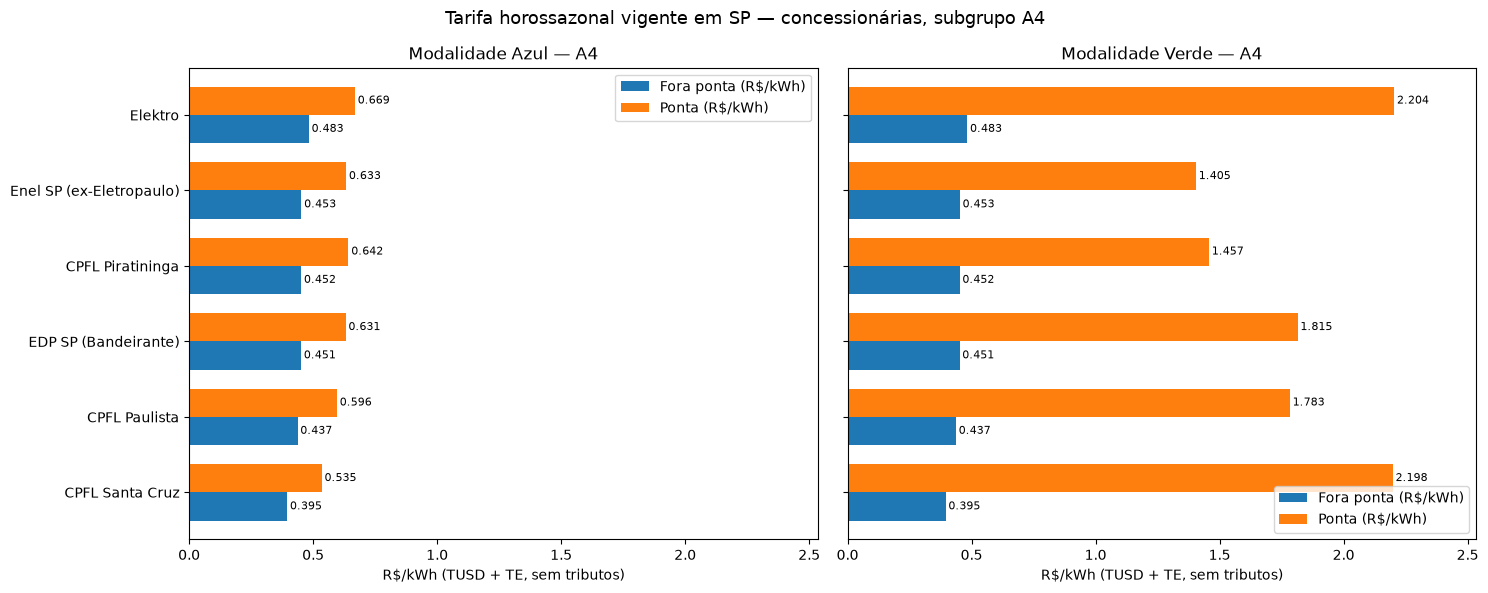

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, mod in zip(axes, ["Azul", "Verde"]):
    d = (a4_conc[a4_conc["DscModalidadeTarifaria"] == mod]
         .set_index("Distribuidora")[["Fora ponta (R$/kWh)", "Ponta (R$/kWh)"]]
         .sort_values("Fora ponta (R$/kWh)"))
    d.plot(kind="barh", ax=ax, width=0.75)
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.3f", padding=2, fontsize=8)
    ax.set_title(f"Modalidade {mod} — A4")
    ax.set_xlabel("R$/kWh (TUSD + TE, sem tributos)")
    ax.set_ylabel("")
    ax.set_xlim(0, max(a4_conc["Ponta (R$/kWh)"]) * 1.15)
fig.suptitle("Tarifa horossazonal vigente em SP — concessionárias, subgrupo A4", fontsize=13)
plt.tight_layout()
plt.show()

## 12. Todos os subgrupos do Grupo A (concessionárias de SP)

Os subgrupos de maior tensão (A2, A3, A3a) têm TUSD menor; o AS é o subterrâneo (Enel SP).

In [56]:
todos = (tab_kwh[tab_kwh["Tipo"] == "Concessionária"]
         .sort_values(["DscModalidadeTarifaria", "DscSubGrupo", "Distribuidora"])
         .drop(columns="Tipo"))
display(todos.style.format(fmt).hide(axis="index"))

Distribuidora,DscModalidadeTarifaria,DscSubGrupo,Fora ponta (R$/kWh),Ponta (R$/kWh),Ponta / Fora ponta (x)
CPFL Paulista,Azul,A2,0.3674,0.5265,1.43
CPFL Piratininga,Azul,A2,0.3993,0.5900,1.48
CPFL Santa Cruz,Azul,A2,0.3281,0.4675,1.42
EDP SP (Bandeirante),Azul,A2,0.3907,0.5705,1.46
Elektro,Azul,A2,0.4068,0.5928,1.46
Enel SP (ex-Eletropaulo),Azul,A2,0.3968,0.5773,1.46
CPFL Paulista,Azul,A3,0.4012,0.5603,1.40
CPFL Santa Cruz,Azul,A3,0.3519,0.4912,1.40
Elektro,Azul,A3,0.4512,0.6372,1.41
CPFL Paulista,Azul,A3a,0.4370,0.5960,1.36


## 13. De onde vem o valor? TE x TUSD (A4)

Na modalidade **Verde**, o custo de ponta é muito maior porque a TUSD de ponta em R$/MWh embute a cobrança de demanda de ponta (na Azul, a demanda de ponta é cobrada em R$/kW, separadamente).

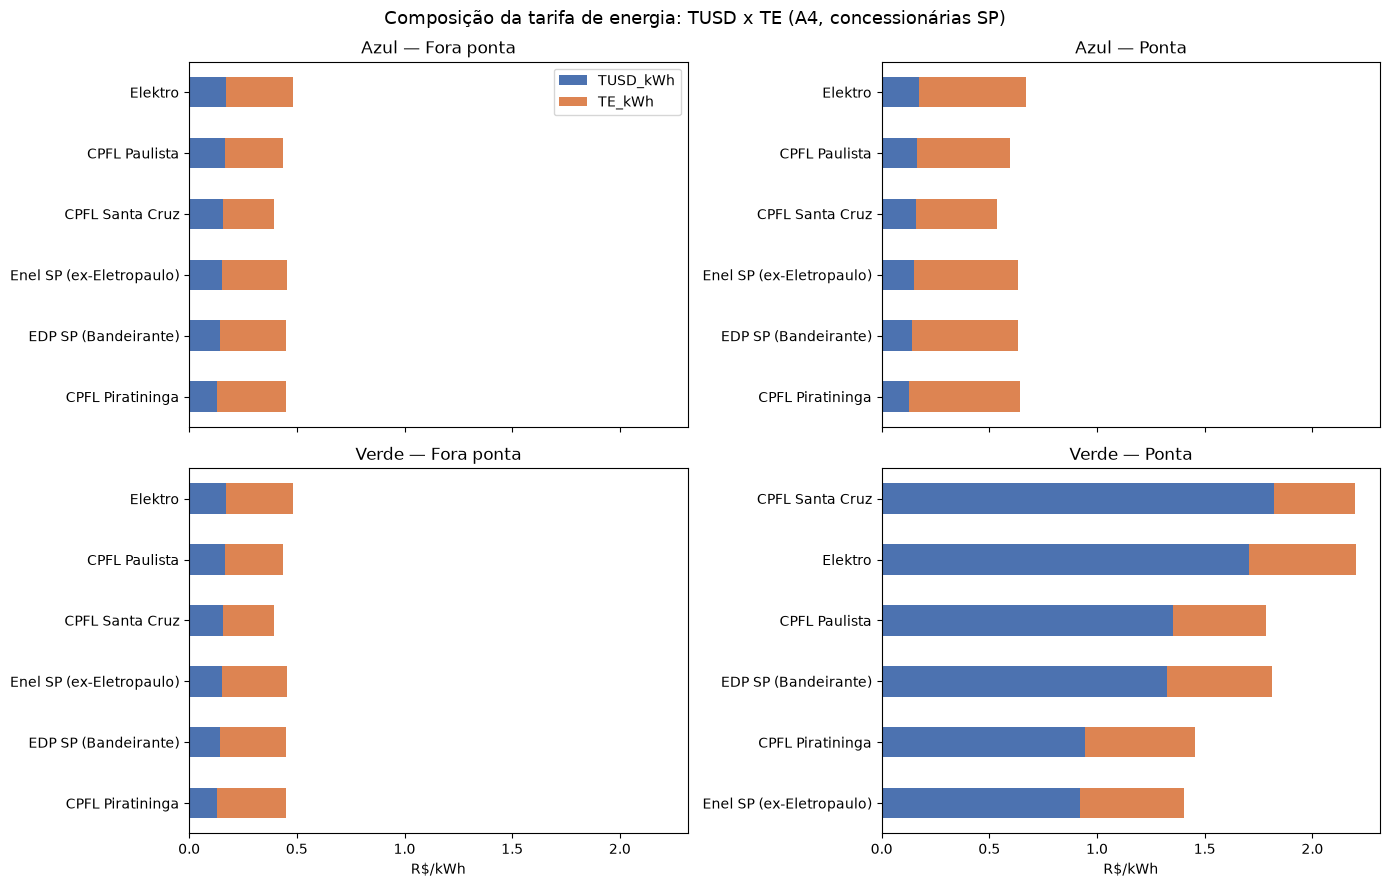

TE_kWh         TUSD_kWh  \
NomPostoTarifario                               Fora ponta Ponta Fora ponta   
Distribuidora            DscModalidadeTarifaria                               
CPFL Paulista            Azul                         0.27  0.43       0.16   
                         Verde                        0.27  0.43       0.16   
CPFL Piratininga         Azul                         0.32  0.51       0.13   
                         Verde                        0.32  0.51       0.13   
CPFL Santa Cruz          Azul                         0.24  0.38       0.16   
                         Verde                        0.24  0.38       0.16   
EDP SP (Bandeirante)     Azul                         0.31  0.49       0.14   
                         Verde                        0.31  0.49       0.14   
Elektro                  Azul                         0.31  0.50       0.17   
                         Verde                        0.31  0.50       0.17   
Enel SP (ex-Eletropaulo) Azul                         0.30  0.48       0.15   
                         Verde                        0.30  0.48       0.15   

                                                       Total_kWh        
NomPostoTarifario                               Ponta Fora ponta Ponta  
Distribuidora            DscModalidadeTarifaria                         
CPFL Paulista            Azul                    0.16       0.44  0.60  
                         Verde                   1.35       0.44  1.78  
CPFL Piratininga         Azul                    0.13       0.45  0.64  
                         Verde                   0.94       0.45  1.46  
CPFL Santa Cruz          Azul                    0.16       0.40  0.53  
                         Verde                   1.82       0.40  2.20  
EDP SP (Bandeirante)     Azul                    0.14       0.45  0.63  
                         Verde                   1.33       0.45  1.81  
Elektro                  Azul                    0.17       0.48  0.67  
                         Verde                   1.71       0.48  2.20  
Enel SP (ex-Eletropaulo) Azul                    0.15       0.45  0.63  
                         Verde                   0.92       0.45  1.40

In [57]:
comp = energia[(energia["DscSubGrupo"] == "A4") & (energia["Tipo"] == "Concessionária")]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for i, mod in enumerate(["Azul", "Verde"]):
    for j, posto in enumerate(["Fora ponta", "Ponta"]):
        ax = axes[i, j]
        d = (comp[(comp["DscModalidadeTarifaria"] == mod) & (comp["NomPostoTarifario"] == posto)]
             .set_index("Distribuidora")[["TUSD_kWh", "TE_kWh"]].sort_values("TUSD_kWh"))
        d.plot(kind="barh", stacked=True, ax=ax, color=["#4C72B0", "#DD8452"], legend=(i == 0 and j == 0))
        ax.set_title(f"{mod} — {posto}")
        ax.set_xlabel("R$/kWh"); ax.set_ylabel("")
fig.suptitle("Composição da tarifa de energia: TUSD x TE (A4, concessionárias SP)", fontsize=13)
plt.tight_layout()
plt.show()

display(comp.pivot_table(index=["Distribuidora", "DscModalidadeTarifaria"], columns="NomPostoTarifario",
                         values=["TUSD_kWh", "TE_kWh", "Total_kWh"]).round(4))

## 14. Tarifas de demanda (R$/kW) — não convertíveis em R$/kWh

A TUSD em **R$/kW** remunera a potência contratada. Mostramos as tarifas vigentes para A4:
**Azul** tem demanda de ponta e de fora ponta; **Verde** tem uma única demanda (`Não se aplica`).

In [58]:
demanda = vig_padrao[(vig_padrao["DscUnidadeTerciaria"] == "kW") & (vig_padrao["DscSubGrupo"] == "A4")].copy()
dem_tab = (demanda.pivot_table(index=["Tipo", "Distribuidora", "DscModalidadeTarifaria"],
                               columns="NomPostoTarifario", values="VlrTUSD", aggfunc="first")
           .rename(columns={"Fora ponta": "Fora ponta (R$/kW)", "Ponta": "Ponta (R$/kW)", "Não se aplica": "Única (R$/kW)"})
           .reset_index())
dem_tab.columns.name = None
display(dem_tab[dem_tab["Tipo"] == "Concessionária"].drop(columns="Tipo")
        .style.format("{:.2f}", subset=[c for c in dem_tab.columns if "R$/kW" in c], na_rep="—").hide(axis="index"))

Distribuidora,DscModalidadeTarifaria,Fora ponta (R$/kW),Única (R$/kW),Ponta (R$/kW)
CPFL Paulista,Azul,16.53,—,48.90
CPFL Paulista,Verde,—,16.53,—
CPFL Piratininga,Azul,12.01,—,33.54
CPFL Piratininga,Verde,—,12.01,—
CPFL Santa Cruz,Azul,21.40,—,68.39
CPFL Santa Cruz,Verde,—,21.40,—
EDP SP (Bandeirante),Azul,12.02,—,48.65
EDP SP (Bandeirante),Verde,—,12.02,—
Elektro,Azul,25.20,—,63.10
Elektro,Verde,—,25.20,—


## 15. Simulação: custo **efetivo** em R$/kWh (energia + demanda)

Para comparar **Azul x Verde** de forma justa é preciso juntar energia e demanda. O custo efetivo por kWh depende do perfil do consumidor; as premissas abaixo são **ilustrativas e editáveis**:

| Parâmetro | Valor | Significado |
|---|---|---|
| `FATOR_CARGA` | 0,60 | consumo mensal ÷ (demanda contratada × 730 h) |
| `PARTICIPACAO_PONTA` | 0,10 | fatia do consumo (kWh) que ocorre na ponta |
| Demanda contratada | igual na ponta e fora ponta | caso da Azul |

**Fórmula (por kWh consumido):**

`custo = p × energia_ponta + (1 − p) × energia_fora_ponta + soma_das_demandas_R$/kW ÷ (730 × FC)`

Tributos e bandeiras não estão incluídos.

Premissas: fator de carga = 60%, consumo na ponta = 10%


Distribuidora,DscModalidadeTarifaria,Energia (R$/kWh),Demanda (R$/kWh),Custo efetivo (R$/kWh)
CPFL Santa Cruz,Azul,0.4093,0.2050,0.6143
CPFL Paulista,Azul,0.4529,0.1494,0.6023
EDP SP (Bandeirante),Azul,0.4693,0.1385,0.6078
CPFL Piratininga,Azul,0.4708,0.1040,0.5748
Enel SP (ex-Eletropaulo),Azul,0.4706,0.1160,0.5865
Elektro,Azul,0.5012,0.2016,0.7028
CPFL Santa Cruz,Verde,0.5756,0.0489,0.6245
CPFL Paulista,Verde,0.5716,0.0377,0.6094
EDP SP (Bandeirante),Verde,0.5876,0.0274,0.6151
CPFL Piratininga,Verde,0.5523,0.0274,0.5797


DscModalidadeTarifaria,Azul,Verde,Mais barata,Diferença (R$/kWh)
Distribuidora,,,,
CPFL Piratininga,0.5748,0.5797,Azul,0.0049
Enel SP (ex-Eletropaulo),0.5865,0.5912,Azul,0.0047
CPFL Paulista,0.6023,0.6094,Azul,0.0071
EDP SP (Bandeirante),0.6078,0.6151,Azul,0.0073
CPFL Santa Cruz,0.6143,0.6245,Azul,0.0102
Elektro,0.7028,0.7123,Azul,0.0095


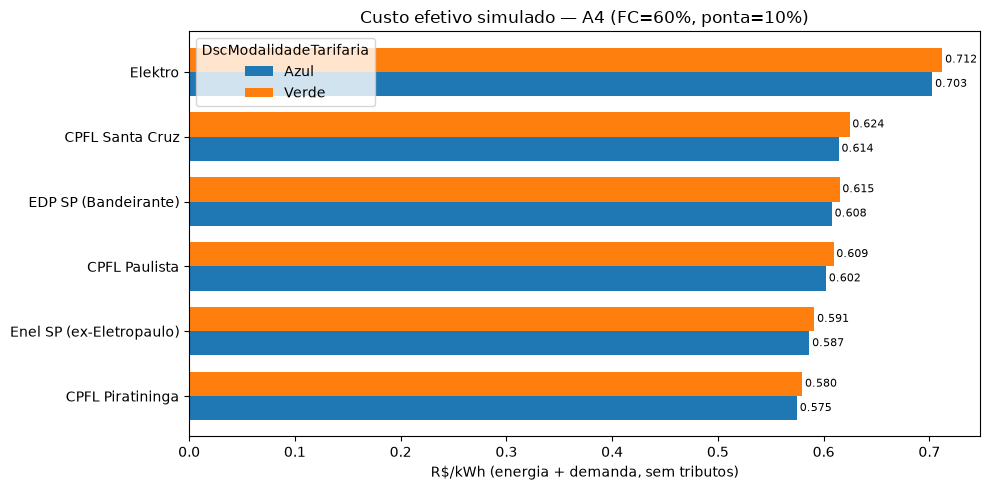

In [59]:
FATOR_CARGA = 0.60
PARTICIPACAO_PONTA = 0.10
HORAS_MES = 730

def custo_efetivo(tab_energia, tab_demanda, fc=FATOR_CARGA, p=PARTICIPACAO_PONTA):
    e = tab_energia.set_index(["Distribuidora", "DscModalidadeTarifaria"])
    d = tab_demanda.set_index(["Distribuidora", "DscModalidadeTarifaria"])
    out = pd.DataFrame(index=e.index)
    out["Energia (R$/kWh)"] = p * e["Ponta (R$/kWh)"] + (1 - p) * e["Fora ponta (R$/kWh)"]
    dem_total = d["Ponta (R$/kW)"].fillna(0) + d["Fora ponta (R$/kW)"].fillna(0) + d["Única (R$/kW)"].fillna(0)
    out["Demanda (R$/kWh)"] = dem_total.reindex(out.index) / (HORAS_MES * fc)
    out["Custo efetivo (R$/kWh)"] = out["Energia (R$/kWh)"] + out["Demanda (R$/kWh)"]
    return out.reset_index()

dem_conc = dem_tab[dem_tab["Tipo"] == "Concessionária"]
sim = custo_efetivo(a4_conc, dem_conc)
sim_pivot = sim.pivot(index="Distribuidora", columns="DscModalidadeTarifaria", values="Custo efetivo (R$/kWh)")
sim_pivot["Mais barata"] = np.where(sim_pivot["Azul"] < sim_pivot["Verde"], "Azul", "Verde")
sim_pivot["Diferença (R$/kWh)"] = (sim_pivot["Verde"] - sim_pivot["Azul"]).abs()

print(f"Premissas: fator de carga = {FATOR_CARGA:.0%}, consumo na ponta = {PARTICIPACAO_PONTA:.0%}")
display(sim.style.format({c: "{:.4f}" for c in sim.columns if "R$/kWh" in c}).hide(axis="index"))
display(sim_pivot.sort_values("Azul").style.format({"Azul": "{:.4f}", "Verde": "{:.4f}", "Diferença (R$/kWh)": "{:.4f}"}))

ax = sim_pivot[["Azul", "Verde"]].sort_values("Azul").plot(kind="barh", figsize=(10, 5), width=0.75)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.3f", padding=2, fontsize=8)
ax.set_title(f"Custo efetivo simulado — A4 (FC={FATOR_CARGA:.0%}, ponta={PARTICIPACAO_PONTA:.0%})")
ax.set_xlabel("R$/kWh (energia + demanda, sem tributos)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

### Sensibilidade ao perfil de consumo

Quanto maior o consumo na ponta, mais a **Azul** tende a compensar frente à **Verde** (cuja TUSD de ponta em R$/MWh é elevada). Abaixo, o custo efetivo para uma distribuidora de referência variando a fatia de consumo na ponta.

In [60]:
REF = "CPFL Paulista"
linhas = []
for p in [0.05, 0.10, 0.15, 0.20, 0.30]:
    s = custo_efetivo(a4_conc, dem_conc, fc=FATOR_CARGA, p=p)
    s = s[s["Distribuidora"] == REF].set_index("DscModalidadeTarifaria")["Custo efetivo (R$/kWh)"]
    linhas.append({"Consumo na ponta": f"{p:.0%}", "Azul": s["Azul"], "Verde": s["Verde"],
                   "Mais barata": "Azul" if s["Azul"] < s["Verde"] else "Verde"})
sens = pd.DataFrame(linhas)
print(f"{REF} — A4 — fator de carga {FATOR_CARGA:.0%}")
display(sens.style.format({"Azul": "{:.4f}", "Verde": "{:.4f}"}).hide(axis="index"))

CPFL Paulista — A4 — fator de carga 60%


Consumo na ponta,Azul,Verde,Mais barata
5%,0.5943,0.5420,Verde
10%,0.6023,0.6094,Azul
15%,0.6102,0.6767,Azul
20%,0.6182,0.7440,Azul
30%,0.6341,0.8787,Azul


## 16. Evolução histórica do R$/kWh em SP (A4, principais concessionárias)

A série começa em **2015**: até abril/2014 a TE era cobrada nos postos sazonais (`Ponta/Fora ponta seca e úmida`) e os postos `Ponta`/`Fora ponta` traziam só a TUSD — somar os dois nesse período subestimaria o R$/kWh (ver seção 17 para o período sazonal).

Para cada ano usamos a **última vigência iniciada no ano** (tarifa vigente ao fim do ano). `CPFL Santa Cruz` junta o registro legado (pré-2018) e o atual (pós-incorporação das demais CPFL do interior); as séries ligadas a essa distribuidora têm quebra estrutural em 2018.

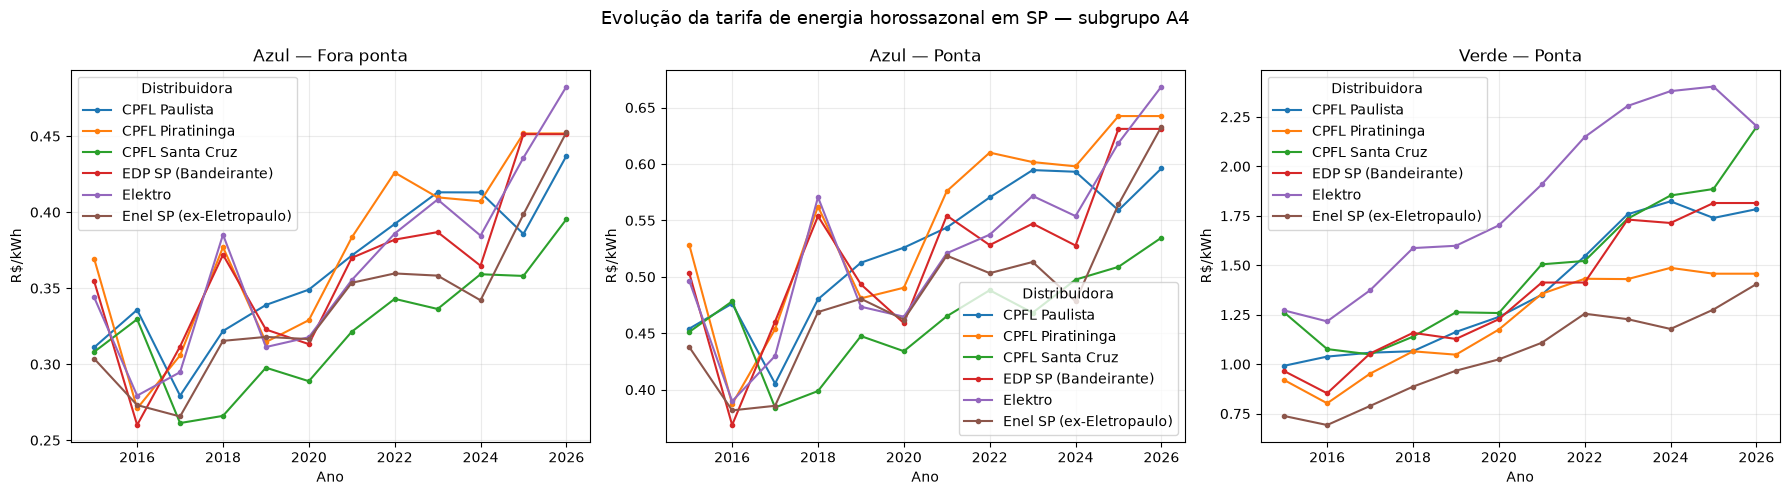

NomPostoTarifario    Fora ponta                                   \
Distribuidora     CPFL Paulista CPFL Piratininga CPFL Santa Cruz   
Ano                                                                
2015                       0.31             0.37            0.31   
2016                       0.34             0.27            0.33   
2017                       0.28             0.31            0.26   
2018                       0.32             0.38            0.27   
2019                       0.34             0.31            0.30   
2020                       0.35             0.33            0.29   
2021                       0.37             0.38            0.32   
2022                       0.39             0.43            0.34   
2023                       0.41             0.41            0.34   
2024                       0.41             0.41            0.36   
2025                       0.39             0.45            0.36   
2026                       0.44             0.45            0.40   

NomPostoTarifario                                                        \
Distribuidora     EDP SP (Bandeirante) Elektro Enel SP (ex-Eletropaulo)   
Ano                                                                       
2015                              0.35    0.34                     0.30   
2016                              0.26    0.28                     0.27   
2017                              0.31    0.29                     0.27   
2018                              0.37    0.39                     0.32   
2019                              0.32    0.31                     0.32   
2020                              0.31    0.32                     0.32   
2021                              0.37    0.36                     0.35   
2022                              0.38    0.39                     0.36   
2023                              0.39    0.41                     0.36   
2024                              0.36    0.38                     0.34   
2025                              0.45    0.44                     0.40   
2026                              0.45    0.48                     0.45   

NomPostoTarifario         Ponta                                   \
Distribuidora     CPFL Paulista CPFL Piratininga CPFL Santa Cruz   
Ano                                                                
2015                       0.45             0.53            0.45   
2016                       0.48             0.39            0.48   
2017                       0.41             0.45            0.38   
2018                       0.48             0.56            0.40   
2019                       0.51             0.48            0.45   
2020                       0.53             0.49            0.43   
2021                       0.54             0.58            0.47   
2022                       0.57             0.61            0.49   
2023                       0.59             0.60            0.47   
2024                       0.59             0.60            0.50   
2025                       0.56             0.64            0.51   
2026                       0.60             0.64            0.53   

NomPostoTarifario                                                        
Distribuidora     EDP SP (Bandeirante) Elektro Enel SP (ex-Eletropaulo)  
Ano                                                                      
2015                              0.50    0.50                     0.44  
2016                              0.37    0.39                     0.38  
2017                              0.46    0.43                     0.39  
2018                              0.55    0.57                     0.47  
2019                              0.49    0.47                     0.48  
2020                              0.46    0.46                     0.46  
2021                              0.55    0.52                     0.52  
2022                              0.53    0.54                     0.50  
2023              

In [61]:
hist = tarifa_aplicacao_padrao(sp[sp["SigAgente"].isin(PRINCIPAIS + ["CPFL SANTA CRUZ"])])
hist = hist[(hist["DscUnidadeTerciaria"] == "MWh") & (hist["DscSubGrupo"] == "A4")
            & (hist["NomPostoTarifario"].isin(["Ponta", "Fora ponta"]))].copy()
hist["R$/kWh"] = (hist["VlrTUSD"].fillna(0) + hist["VlrTE"].fillna(0)) / 1000
hist["Ano"] = hist["DatInicioVigencia"].dt.year
hist = hist[hist["Ano"] >= 2015]   # antes disso a TE estava nos postos seca/úmida

ult = (hist.sort_values("DatInicioVigencia")
       .groupby(["Distribuidora", "DscModalidadeTarifaria", "NomPostoTarifario", "Ano"], as_index=False).last())

series = {"Azul — Fora ponta": ("Azul", "Fora ponta"), "Azul — Ponta": ("Azul", "Ponta"), "Verde — Ponta": ("Verde", "Ponta")}
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, (titulo, (mod, posto)) in zip(axes, series.items()):
    d = (ult[(ult["DscModalidadeTarifaria"] == mod) & (ult["NomPostoTarifario"] == posto)]
         .pivot(index="Ano", columns="Distribuidora", values="R$/kWh"))
    d.plot(ax=ax, marker="o", markersize=3)
    ax.set_title(titulo); ax.set_ylabel("R$/kWh"); ax.grid(alpha=0.25)
fig.suptitle("Evolução da tarifa de energia horossazonal em SP — subgrupo A4", fontsize=13)
plt.tight_layout(); plt.show()

ev = (ult[(ult["DscModalidadeTarifaria"] == "Azul")]
      .pivot_table(index="Ano", columns=["NomPostoTarifario", "Distribuidora"], values="R$/kWh"))
display(ev.round(4))

### Variação acumulada

Quanto a tarifa subiu entre o primeiro ano com dado e o último vigente.

In [62]:
az = ult[ult["DscModalidadeTarifaria"] == "Azul"]
linhas = []
for (dist, posto), g in az.groupby(["Distribuidora", "NomPostoTarifario"]):
    g = g.sort_values("Ano")
    g = g[g["R$/kWh"] > 0]
    if len(g) >= 2:
        linhas.append({"Distribuidora": dist, "Posto": posto, "Ano inicial": int(g["Ano"].iloc[0]), "R$/kWh inicial": g["R$/kWh"].iloc[0],
                       "Ano final": int(g["Ano"].iloc[-1]), "R$/kWh final": g["R$/kWh"].iloc[-1],
                       "Variação (%)": (g["R$/kWh"].iloc[-1] / g["R$/kWh"].iloc[0] - 1) * 100})
var = pd.DataFrame(linhas).sort_values(["Posto", "Variação (%)"], ascending=[True, False])
display(var.style.format({"R$/kWh inicial": "{:.4f}", "R$/kWh final": "{:.4f}", "Variação (%)": "{:.1f}"}).hide(axis="index"))

Distribuidora,Posto,Ano inicial,R$/kWh inicial,Ano final,R$/kWh final,Variação (%)
Enel SP (ex-Eletropaulo),Fora ponta,2015,0.3036,2026,0.4525,49.0
CPFL Paulista,Fora ponta,2015,0.3111,2026,0.4370,40.5
Elektro,Fora ponta,2015,0.3439,2026,0.4826,40.3
CPFL Santa Cruz,Fora ponta,2015,0.3081,2026,0.3953,28.3
EDP SP (Bandeirante),Fora ponta,2015,0.3544,2026,0.4513,27.3
CPFL Piratininga,Fora ponta,2015,0.3693,2026,0.4518,22.3
Enel SP (ex-Eletropaulo),Ponta,2015,0.4379,2026,0.6330,44.6
Elektro,Ponta,2015,0.4966,2026,0.6686,34.6
CPFL Paulista,Ponta,2015,0.4541,2026,0.5960,31.3
EDP SP (Bandeirante),Ponta,2015,0.5034,2026,0.6311,25.4


## 17. Sazonalidade seca x úmida em SP

Os postos `Ponta seca/úmida` e `Fora ponta seca/úmida` aparecem apenas em ciclos antigos. Veja quais distribuidoras de SP os usaram e quanto valia o kWh.

In [63]:
saz = tarifa_aplicacao_padrao(sp[sp["NomPostoTarifario"].str.contains("seca|úmida", na=False)])
saz = saz[saz["DscUnidadeTerciaria"] == "MWh"].copy()
saz["R$/kWh"] = (saz["VlrTUSD"].fillna(0) + saz["VlrTE"].fillna(0)) / 1000
print("Período com posto sazonal em SP:", saz["DatInicioVigencia"].min().date(), "a", saz["DatFimVigencia"].max().date())
print("Distribuidoras:", sorted(saz["Distribuidora"].unique()))

saz_res = (saz[saz["DscModalidadeTarifaria"] == "Azul"].groupby(["Distribuidora", "DscSubGrupo", "NomPostoTarifario"])["R$/kWh"]
           .median().unstack("NomPostoTarifario"))
saz_res["Seco/Úmido ponta (%)"] = (saz_res["Ponta seca"] / saz_res["Ponta úmida"] - 1) * 100
saz_res["Seco/Úmido fora ponta (%)"] = (saz_res["Fora ponta seca"] / saz_res["Fora ponta úmida"] - 1) * 100
display(saz_res.round(4))

Período com posto sazonal em SP: 2010-02-03 a 2014-04-14
Distribuidoras: ['CEDRAP', 'CEDRI', 'CERIM', 'CERIPa', 'CERIS', 'CERMC', 'CERPRO', 'CERRP', 'CETRIL', 'CNEE', 'CPFL Jaguari', 'CPFL Leste Paulista', 'CPFL Mococa', 'CPFL Paulista', 'CPFL Piratininga', 'CPFL Santa Cruz', 'CPFL Sul Paulista', 'EDEVP', 'EDP SP (Bandeirante)', 'EEB (Bragantina)', 'Elektro', 'Enel SP (ex-Eletropaulo)']


,NomPostoTarifario,Fora ponta seca,Fora ponta úmida,Ponta seca,Ponta úmida,Seco/Úmido ponta (%),Seco/Úmido fora ponta (%)
Distribuidora,DscSubGrupo,,,,,,
CEDRAP,A4,0.16,0.15,0.26,0.23,10.57,9.75
CEDRI,A4,0.17,0.14,0.24,0.20,19.72,23.48
CERIM,A4,0.19,0.17,0.31,0.28,10.77,10.09
CERIPa,A4,0.14,0.13,0.23,0.21,10.46,9.59
CERIS,A4,0.18,0.16,0.29,0.26,10.63,9.85
CERMC,A4,0.15,0.14,0.24,0.22,10.62,9.83
CERPRO,A4,0.19,0.17,0.30,0.27,10.76,10.05
CERRP,A4,0.15,0.13,0.24,0.22,10.69,9.94
CETRIL,A4,0.19,0.17,0.30,0.27,10.67,9.91


## 18. Exportar o resultado

Salva a tabela principal (R$/kWh vigente por distribuidora, modalidade e subgrupo).

In [64]:
saida = tab_kwh.copy()
saida["Data de referência"] = DATA_ANALISE.date()
saida.to_csv("tarifa_horossazonal_sp_vigente_kwh.csv", index=False, sep=";", decimal=",", encoding="utf-8-sig")
print(f"Arquivo salvo: tarifa_horossazonal_sp_vigente_kwh.csv ({len(saida)} linhas)")

Arquivo salvo: tarifa_horossazonal_sp_vigente_kwh.csv (51 linhas)


## 19. Conclusões — estado de São Paulo

**Resposta direta (tarifas vigentes em 06/10/2026, subgrupo A4, concessionárias, TUSD + TE, sem tributos):**

| Modalidade | Posto | Faixa em SP (R$/kWh) | Menor | Maior |
|---|---|---|---|---|
| Azul | Fora ponta | 0,395 – 0,483 | CPFL Santa Cruz | Elektro |
| Azul | Ponta | 0,535 – 0,669 | CPFL Santa Cruz | Elektro |
| Verde | Fora ponta | 0,395 – 0,483 | CPFL Santa Cruz | Elektro |
| Verde | Ponta | 1,405 – 2,204 | Enel SP | Elektro / CPFL Santa Cruz |

### O que os números mostram
- **Fora ponta** é igual na Azul e na Verde: na faixa de **R$ 0,40 a R$ 0,48/kWh**.
- **Azul:** a ponta custa apenas **1,35x a 1,42x** o fora ponta, porque a demanda de ponta é cobrada à parte, em R$/kW.
- **Verde:** a ponta custa de **3,1x a 5,6x** o fora ponta, porque a TUSD de ponta em R$/MWh embute a demanda de ponta. Esse valor alto **não é o custo efetivo** de quem opera pouco na ponta.
- **Composição:** a TE responde por cerca de 60–70% do kWh fora ponta; a TUSD por 30–40%.
- **Cooperativas:** na Azul, ponta e fora ponta têm o mesmo valor (razão 1,00x); na Verde a ponta é muito mais cara (3x a 9x).

### Azul x Verde (simulação — premissas na seção 15)
Com fator de carga de 60% e 10% do consumo na ponta, o custo efetivo (energia + demanda) fica **muito próximo** entre as modalidades, com diferença de apenas R$ 0,005 a R$ 0,010/kWh a favor da Azul. Na sensibilidade (CPFL Paulista), com **5% de consumo na ponta a Verde fica mais barata**; a partir de ~10% a Azul passa a compensar, e a diferença cresce rapidamente. A escolha depende do perfil real de carga.

### Evolução (2015–2026, A4 Azul)
- Fora ponta: alta de **22% (CPFL Piratininga) a 49% (Enel SP)**.
- Ponta: alta de **18% (CPFL Santa Cruz) a 45% (Enel SP)**.

### Limitações
- **O CSV não possui UF**: a lista de distribuidoras de SP foi montada manualmente. As cooperativas (exceto CERIPa, confirmada em fonte pública) foram associadas a SP por CNPJ/histórico e **devem ser conferidas**.
- Os valores **não incluem ICMS, PIS/COFINS nem bandeiras tarifárias**; o custo final faturado é maior.
- TUSD em **R$/kW** (demanda) não vira R$/kWh sem premissa de fator de carga — por isso a seção 15 é uma simulação ilustrativa.
- Antes de maio/2014 a TE estava nos postos seca/úmida; a série histórica foi cortada em 2015 por esse motivo.
- Tarifas especiais (APE, SCEE, irrigação, acessantes nominais) foram excluídas.